### Bayesian Logistic Regression

In [1]:
# Run this script to add the src directory to the python path

from notebook_utils import modify_sys_path, get_src_dir_path

modify_sys_path()

In [9]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from matplotlib.cm import get_cmap
import numpy as np
import re
from csaps import csaps
from scipy.interpolate import UnivariateSpline
from scipy import stats

from src.bandit import ButtonsBandit
import scienceplots

In [5]:
# results_directory = 'results/logistic_regression_3/experiment_2/active_learning/dataset_specified/'

# results_directory = 'results/logistic_regression_3/experiment_2_14b_seed_change/'

results_directory = 'results/logistic_regression_3/qwen7b/experiment_2/'

# fig_save_directory = 'figures/logistic_regression/qwen7b/experiment_2/'

shots = 15
D_data = None

for filename in os.listdir(get_src_dir_path(results_directory)):
    if f"D_{shots}" in filename:
        D_data = pd.read_csv(get_src_dir_path(results_directory) + filename)

In [15]:
D_data

,x1,label,note
0,-0.0,0,x1 = -0.0
1,-1.8,0,x1 = -1.8
2,2.3,0,x1 = 2.3
3,-1.6,0,x1 = -1.6
4,-1.4,1,x1 = -1.4
5,-4.6,0,x1 = -4.6
6,7.2,1,x1 = 7.2
7,4.9,1,x1 = 4.9
8,0.2,0,x1 = 0.2
9,6.0,1,x1 = 6.0


In [20]:
def log_prior_dist(bias: float, coeff: float) -> float:
    """
    Prior distribution for theta. Standard normal distribution with mean 0 and standard deviation 1.
    """
    return np.log(stats.norm.pdf(bias, loc=0, scale=1)) +  np.log(stats.norm.pdf(coeff, loc=0, scale=1))

In [12]:
def log_likelihood_dist(bias: float, coeff: float, x: np.ndarray, y: np.ndarray) -> float:
    """
    Likelihood distribution for theta. Logistic regression model.
    """
    p = 1 / (1 + np.exp(-(bias + coeff * x)))
    return np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))

In [17]:
def log_posterior_dist(bias: float, coeff: float, x: np.ndarray, y: np.ndarray) -> float:
    """
    Posterior distribution for theta. Standard normal distribution with mean 0 and standard deviation 1.
    """
    return log_likelihood_dist(bias, coeff, x, y) + log_prior_dist(bias, coeff)

def new_proposal(bias: float, coeff: float) -> tuple:
    """
    Proposal distribution for theta. Standard normal distribution with mean 0 and standard deviation 1.
    """
    new_bias = np.random.normal(loc=bias, scale=0.2)
    new_coeff = np.random.normal(loc=coeff, scale=0.2)
    return new_bias, new_coeff

In [29]:
def acceptance_ratio(bias: float, coeff: float, new_bias: float, new_coeff: float, x: np.ndarray, y: np.ndarray) -> float:
    """
    Acceptance ratio for Metropolis-Hastings algorithm.
    """
    return np.exp(log_posterior_dist(new_bias, new_coeff, x, y) - log_posterior_dist(bias, coeff, x, y))

def metropolis_hastings(D_data: pd.DataFrame, n_samples: int = 1000) -> tuple:
    """
    Metropolis-Hastings algorithm for sampling from the posterior distribution.
    """
    x = D_data['x1'].values
    y = D_data['label'].values
    bias = np.random.normal(loc=0, scale=1)
    coeff = np.random.normal(loc=0, scale=1)
    
    BURN_IN = 1000
    THINNING = 10
    samples = []
    for i in range(n_samples):
        new_bias, new_coeff = new_proposal(bias, coeff)
        alpha = acceptance_ratio(bias, coeff, new_bias, new_coeff, x, y)
        if np.random.rand() < alpha:
            bias = new_bias
            coeff = new_coeff
        samples.append((bias, coeff))
        
    # Remove burn-in samples
    samples = samples[BURN_IN:]
    # Thinning
    samples = samples[::THINNING]
    return np.array(samples)

In [32]:
def mean_conditional_entropy(parameter_samples: np.ndarray, x_test: np.ndarray) -> np.ndarray:
    """
    Calculate the mean conditional entropy over samples.
    """

    # Compute probabilities for each sample for each x_test
    
    p_samples = np.array([1 / (1 + np.exp(-(bias + coeff * x_test))) for bias, coeff in parameter_samples])
    
    entropies = - p_samples * np.log2(p_samples) - (1 - p_samples) * np.log2(1 - p_samples)
    
    # Take the mean over samples
    mean_entropies = np.mean(entropies, axis=0)
    return mean_entropies  

In [ ]:
samples = metropolis_hastings(D_data, n_samples=10000)


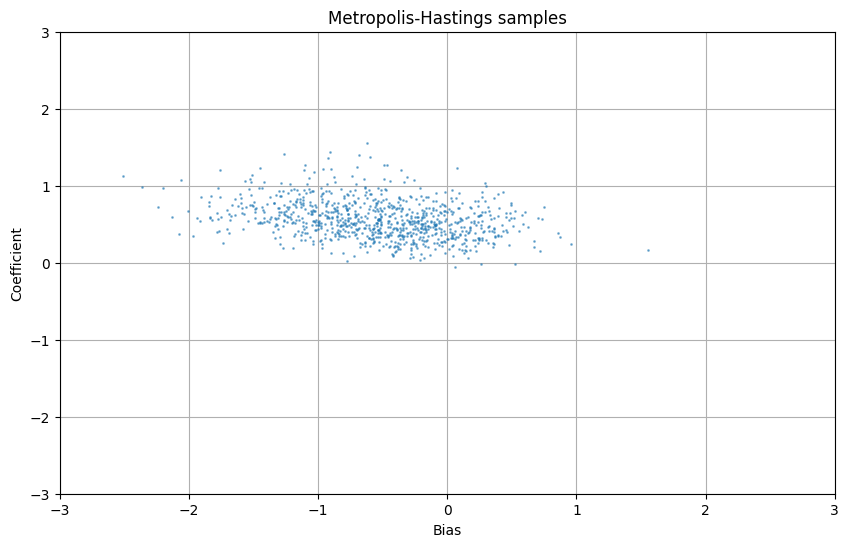

In [31]:
plt.figure(figsize=(10, 6))
plt.plot(samples[:, 0], samples[:, 1], 'o', markersize=1, alpha=0.5)
plt.title('Metropolis-Hastings samples')
plt.xlabel('Bias')
plt.ylabel('Coefficient')
plt.xlim(-3, 3)
plt.ylim(-3, 3)
plt.grid()
plt.show()

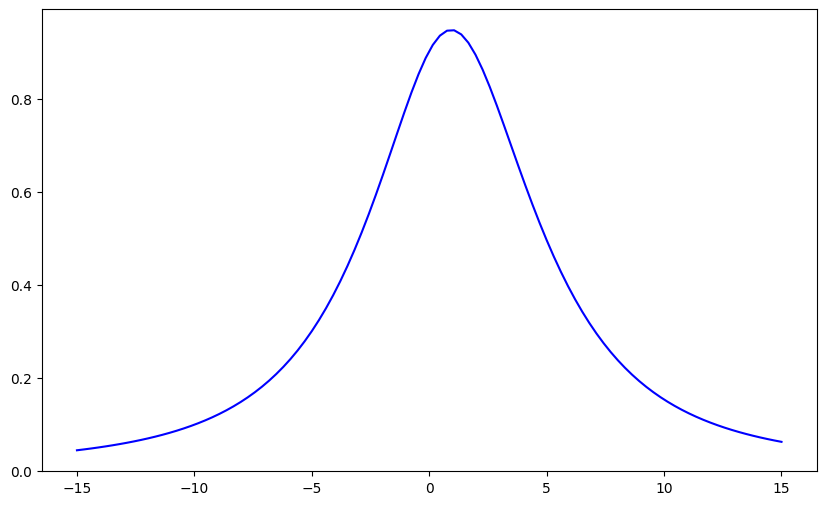

In [35]:
# plot the mean conditional entropy
x_test = np.linspace(-15, 15, 100)
mean_entropies = mean_conditional_entropy(samples, x_test)
plt.figure(figsize=(10, 6))
plt.plot(x_test, mean_entropies, label='Mean Conditional Entropy', color='blue')